<a href="https://colab.research.google.com/github/nayansc722-stack/OT-Security-Projects/blob/Modbus-Analyser/modbus_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OT Security Project 1: Modbus TCP Traffic Analyzer & Anomaly Detector

## Objective

Analyze real Modbus TCP network captures to:
1. Understand normal ICS communication patterns
2. Extract device behaviour from raw traffic
3. Detect attack-indicative anomalies
4. Map findings to MITRE ATT&CK for ICS tactics
5. Produce an analyst-grade incident report

---

## Section 0: Environment Setup & PCAP Download

Run this cell first. It installs dependencies and downloads a real ICS PCAP from a public repository.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0: Install dependencies
# Run this cell once. All libraries are free and open-source.
# ─────────────────────────────────────────────────────────────────────────────

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in ['scapy', 'pyshark', 'pandas', 'matplotlib', 'seaborn', 'tabulate', 'requests']:
    install(pkg)

print("✅ All dependencies installed.")

✅ All dependencies installed.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: PCAP Acquisition — tries 3 sources, falls back to synthetic gracefully
#
# You do NOT need to do anything here. Just run the cell.
# If all downloads fail (firewalls, expired links), synthetic mode kicks in
# automatically in Cell 2-DEMO and the full notebook still runs perfectly.
#
# MANUAL OPTION (if you want real traffic):
#   1. Go to https://github.com/automayt/ICS-pcap/tree/master/MODBUS
#   2. Click any .pcap file → click the download button (top right of file view)
#   3. In Colab: Files panel (left sidebar) → Upload → select the .pcap
#   4. Set PCAP_PATH below to '/content/your_file.pcap'
# ─────────────────────────────────────────────────────────────────────────────

import requests, os

PCAP_PATH = '/data/4SICS-GeekLounge-151020.pcap'
os.makedirs('../data', exist_ok=True)

# ── Three independent sources, tried in order
SOURCES = [
    # Source 1: GitHub raw — ITI ICS-Security-Tools (DNP3 Bro captures, has Modbus frames)
    ('ITI/ICS-Security-Tools GitHub',
     'https://raw.githubusercontent.com/automayt/ICS-pcap/master/MODBUS/modbus.pcap'),
    # Source 2: PacketTotal public sample
    ('Wireshark GitLab mirror',
     'https://gitlab.com/wireshark/wireshark/-/raw/master/test/captures/modbus.pcap'),
    # Source 3: OpenICS test data
    ('OpenICS test data',
     'https://raw.githubusercontent.com/ITI/ICS-Security-Tools/master/pcaps/Modbus/modbus_test.pcap'),
]

PCAP_DOWNLOADED = False

if os.path.exists(PCAP_PATH) and os.path.getsize(PCAP_PATH) > 100:
    print(f'✅ PCAP already present: {PCAP_PATH}')
    PCAP_DOWNLOADED = True
else:
    for label, url in SOURCES:
        try:
            print(f'⬇  Trying {label} ...')
            r = requests.get(url, timeout=15,
                             headers={'User-Agent': 'Mozilla/5.0'})
            if r.status_code == 200 and len(r.content) > 100:
                with open(PCAP_PATH, 'wb') as f:
                    f.write(r.content)
                print(f'✅ Downloaded from {label}: {len(r.content)/1024:.1f} KB')
                PCAP_DOWNLOADED = True
                break
            else:
                print(f'   ✗ HTTP {r.status_code} — trying next source')
        except Exception as e:
            print(f'   ✗ {e} — trying next source')

    if not PCAP_DOWNLOADED:
        print()
        print('⚠️  All download sources failed (network restrictions or expired URLs).')
        print('   → The notebook will use SYNTHETIC data automatically. Everything still runs.')
        print()
        print('   To use REAL traffic manually:')
        print('   1. Visit https://github.com/automayt/ICS-pcap/tree/master/MODBUS')
        print('   2. Download any .pcap file to your computer')
        print('   3. In Colab: left sidebar → Files icon → Upload')
        print('   4. Change PCAP_PATH at the top of this cell to the uploaded path')

✅ PCAP already present: /data/4SICS-GeekLounge-151020.pcap


---
## Section 1: Modbus TCP Protocol Primer

Before analysing traffic, we need to understand the structure. This is what makes you sound credible in an interview.

```
Modbus TCP Packet Structure (Port 502)
═══════════════════════════════════════
[ Ethernet / IP / TCP ]
  └─ Modbus Application Data Unit (ADU)
       ├─ MBAP Header (7 bytes)
       │    ├─ Transaction ID   [2B] — increments per request
       │    ├─ Protocol ID      [2B] — always 0x0000 for Modbus
       │    ├─ Length           [2B] — bytes following
       │    └─ Unit ID          [1B] — target PLC slave ID (0-255)
       └─ Protocol Data Unit (PDU)
            ├─ Function Code    [1B] — the COMMAND
            └─ Data             [nB] — registers, coils, values

KEY FUNCTION CODES (memorise these):
  0x01 (01)  — Read Coils               [NORMAL — sensor status reads]
  0x02 (02)  — Read Discrete Inputs     [NORMAL]
  0x03 (03)  — Read Holding Registers   [NORMAL — most common polling]
  0x04 (04)  — Read Input Registers     [NORMAL]
  0x05 (05)  — Write Single Coil        [⚠️  SUSPICIOUS if unexpected source]
  0x06 (06)  — Write Single Register    [⚠️  SUSPICIOUS if unexpected source]
  0x08 (08)  — Diagnostics              [🚨 DANGEROUS — sub-code 0x0001 = RESTART PLC]
  0x0F (15)  — Write Multiple Coils     [🚨 HIGH IMPACT write]
  0x10 (16)  — Write Multiple Registers [🚨 HIGH IMPACT write]
  0x2B (43)  — Read Device Identification [ℹ️  Reconnaissance indicator]

MITRE ATT&CK for ICS mapping:
  Unauthorized writes  → T0836 Modify Parameter
  Diagnostic abuse     → T0816 Device Restart/Shutdown
  FC 0x2B scanning     → T0846 Remote System Discovery
  Cross-unit scanning  → T0843 Program Upload
```

---
## Section 2: Parse PCAP with Scapy

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Parse the PCAP with Scapy and build the raw packet DataFrame
# ─────────────────────────────────────────────────────────────────────────────

from scapy.all import rdpcap, TCP, IP, Raw
import pandas as pd
import struct
from datetime import datetime

MODBUS_PORT = 502

def decode_modbus_pdu(payload: bytes) -> dict:
    """
    Decode a raw Modbus TCP payload.
    Returns a dict with MBAP header fields and PDU function code.
    """
    if len(payload) < 8:
        return None
    try:
        transaction_id = struct.unpack('>H', payload[0:2])[0]
        protocol_id    = struct.unpack('>H', payload[2:4])[0]
        length         = struct.unpack('>H', payload[4:6])[0]
        unit_id        = payload[6]
        function_code  = payload[7]

        # Only valid Modbus (protocol_id == 0)
        if protocol_id != 0:
            return None

        # Extract register/coil address if present (bytes 8-9)
        register_addr = None
        if len(payload) >= 10:
            register_addr = struct.unpack('>H', payload[8:10])[0]

        # Extract value if present (bytes 10-11)
        value = None
        if len(payload) >= 12:
            value = struct.unpack('>H', payload[10:12])[0]

        # Detect error response (function code with high bit set)
        is_error = bool(function_code & 0x80)
        if is_error:
            actual_fc = function_code & 0x7F
            exception_code = payload[8] if len(payload) > 8 else None
        else:
            actual_fc = function_code
            exception_code = None

        return {
            'transaction_id': transaction_id,
            'unit_id': unit_id,
            'function_code': actual_fc,
            'function_code_hex': f'0x{actual_fc:02X}',
            'register_addr': register_addr,
            'value': value,
            'is_error': is_error,
            'exception_code': exception_code,
            'payload_len': length,
        }
    except Exception:
        return None


FC_NAMES = {
    1: 'Read Coils',
    2: 'Read Discrete Inputs',
    3: 'Read Holding Registers',
    4: 'Read Input Registers',
    5: 'Write Single Coil',
    6: 'Write Single Register',
    7: 'Read Exception Status',
    8: 'Diagnostics',
    15: 'Write Multiple Coils',
    16: 'Write Multiple Registers',
    17: 'Report Server ID',
    43: 'Read Device ID (Recon)',
}

def load_pcap_to_dataframe(pcap_path: str) -> pd.DataFrame:
    """Load a PCAP and return all Modbus TCP packets as a DataFrame."""
    print(f"Loading PCAP: {pcap_path}")
    packets = rdpcap(pcap_path)
    print(f"Total packets: {len(packets)}")

    records = []
    for pkt in packets:
        if not (pkt.haslayer(TCP) and pkt.haslayer(IP)):
            continue

        src_port = pkt[TCP].sport
        dst_port = pkt[TCP].dport

        # Only Modbus TCP (port 502)
        if src_port != MODBUS_PORT and dst_port != MODBUS_PORT:
            continue

        if not pkt.haslayer(Raw):
            continue

        payload = bytes(pkt[Raw].load)
        modbus = decode_modbus_pdu(payload)

        if modbus is None:
            continue

        direction = 'REQUEST'  if dst_port == MODBUS_PORT else 'RESPONSE'
        fc = modbus['function_code']

        records.append({
            'timestamp':    float(pkt.time),
            'src_ip':       pkt[IP].src,
            'dst_ip':       pkt[IP].dst,
            'src_port':     src_port,
            'dst_port':     dst_port,
            'direction':    direction,
            'unit_id':      modbus['unit_id'],
            'function_code': fc,
            'fc_hex':       modbus['function_code_hex'],
            'fc_name':      FC_NAMES.get(fc, f'Unknown FC {fc}'),
            'register_addr': modbus['register_addr'],
            'value':        modbus['value'],
            'is_error':     modbus['is_error'],
            'exception_code': modbus['exception_code'],
            'transaction_id': modbus['transaction_id'],
        })

    df = pd.DataFrame(records)
    if not df.empty:
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
    print(f"Modbus TCP packets parsed: {len(df)}")
    return df


# Only attempt parse if a PCAP was actually downloaded
df = None
if PCAP_DOWNLOADED:
    try:
        df = load_pcap_to_dataframe(PCAP_PATH)
        print('\n--- First 5 rows ---')
        print(df.head())
    except Exception as e:
        print(f'⚠️  PCAP parse error: {e}')
        print('   Falling back to synthetic mode in the next cell.')
        df = None
else:
    print('ℹ️  Skipping PCAP parse — no file downloaded. Synthetic mode runs next cell.')

Loading PCAP: /data/4SICS-GeekLounge-151020.pcap
Total packets: 246137
Modbus TCP packets parsed: 0

--- First 5 rows ---
Empty DataFrame
Columns: []
Index: []


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2-DEMO: Synthetic PCAP Generator
#
# If the PCAP download failed OR you just want to run the full notebook
# end-to-end without a real file, this cell generates a realistic synthetic
# dataset that includes both normal and attack-like Modbus traffic.
#
# Set USE_SYNTHETIC = True to use this data.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

USE_SYNTHETIC = (not PCAP_DOWNLOADED) or (df is None) or (len(df) == 0)
# USE_SYNTHETIC = True  # ← uncomment to force synthetic mode regardless

if USE_SYNTHETIC:
    print("⚠️  Using SYNTHETIC data (either no PCAP found, or forced mode)")
    rng = np.random.default_rng(42)

    n_normal = 800
    n_attack = 40

    # Normal polling: master 10.0.0.10 reads registers from 3 PLCs
    base_ts = pd.Timestamp('2024-03-15 08:00:00')
    timestamps = [base_ts + pd.Timedelta(seconds=i * 0.5 + rng.uniform(-0.05, 0.05))
                  for i in range(n_normal)]

    normal_records = []
    plc_ips = ['192.168.1.10', '192.168.1.11', '192.168.1.12']
    for i, ts in enumerate(timestamps):
        plc = plc_ips[i % 3]
        fc  = rng.choice([3, 3, 3, 1, 4], p=[0.6, 0.2, 0.1, 0.05, 0.05])
        normal_records.append({
            'timestamp': ts,
            'src_ip': '10.0.0.10',
            'dst_ip': plc,
            'src_port': rng.integers(1024, 65000),
            'dst_port': 502,
            'direction': 'REQUEST',
            'unit_id': int(plc.split('.')[-1]) - 9,
            'function_code': int(fc),
            'fc_hex': f'0x{fc:02X}',
            'fc_name': FC_NAMES.get(int(fc), '?'),
            'register_addr': int(rng.integers(0, 100)),
            'value': None,
            'is_error': False,
            'exception_code': None,
            'transaction_id': i,
        })

    # Attack traffic: rogue IP writes/scans from 10.0.0.99
    attack_ts_start = base_ts + pd.Timedelta(minutes=45)
    attack_records = []
    attack_fc_pool = [
        (5,  'Write Single Coil'),
        (6,  'Write Single Register'),
        (8,  'Diagnostics'),          # ← PLC restart attempt
        (16, 'Write Multiple Registers'),
        (43, 'Read Device ID (Recon)'),
    ]
    for i in range(n_attack):
        fc_val, fc_name = attack_fc_pool[i % len(attack_fc_pool)]
        attack_records.append({
            'timestamp': attack_ts_start + pd.Timedelta(seconds=i * 2),
            'src_ip': '10.0.0.99',   # rogue IP — not authorised master
            'dst_ip': rng.choice(plc_ips),
            'src_port': int(rng.integers(1024, 65000)),
            'dst_port': 502,
            'direction': 'REQUEST',
            'unit_id': int(rng.integers(1, 5)),
            'function_code': fc_val,
            'fc_hex': f'0x{fc_val:02X}',
            'fc_name': fc_name,
            'register_addr': int(rng.integers(0, 200)),
            'value': int(rng.integers(0, 65535)),
            'is_error': False,
            'exception_code': None,
            'transaction_id': n_normal + i,
        })

    df = pd.DataFrame(normal_records + attack_records).sort_values('timestamp').reset_index(drop=True)
    print(f"✅ Synthetic dataset generated: {len(df)} packets ({n_normal} normal + {n_attack} attack)")
else:
    print("✅ Using real PCAP data")

df.head(10)

⚠️  Using SYNTHETIC data (either no PCAP found, or forced mode)
✅ Synthetic dataset generated: 840 packets (800 normal + 40 attack)


,timestamp,src_ip,dst_ip,src_port,dst_port,direction,unit_id,function_code,fc_hex,fc_name,register_addr,value,is_error,exception_code,transaction_id
0,2024-03-15 08:00:00.027395604,10.0.0.10,192.168.1.10,53864,502,REQUEST,1,3,0x03,Read Holding Registers,31,NaN,False,None,0
1,2024-03-15 08:00:00.493887843,10.0.0.10,192.168.1.11,10488,502,REQUEST,2,3,0x03,Read Holding Registers,59,NaN,False,None,1
2,2024-03-15 08:00:01.035859791,10.0.0.10,192.168.1.12,50695,502,REQUEST,3,3,0x03,Read Holding Registers,14,NaN,False,None,2
3,2024-03-15 08:00:01.519736802,10.0.0.10,192.168.1.10,4877,502,REQUEST,1,3,0x03,Read Holding Registers,17,NaN,False,None,3
4,2024-03-15 08:00:01.959417734,10.0.0.10,192.168.1.11,8787,502,REQUEST,2,3,0x03,Read Holding Registers,99,NaN,False,None,4
5,2024-03-15 08:00:02.547562235,10.0.0.10,192.168.1.12,60148,502,REQUEST,3,3,0x03,Read Holding Registers,1,NaN,False,None,5
6,2024-03-15 08:00:03.026113970,10.0.0.10,192.168.1.10,37989,502,REQUEST,1,4,0x04,Read Input Registers,58,NaN,False,None,6
7,2024-03-15 08:00:03.528606430,10.0.0.10,192.168.1.11,37662,502,REQUEST,2,3,0x03,Read Holding Registers,89,NaN,False,None,7
8,2024-03-15 08:00:03.962811363,10.0.0.10,192.168.1.12,27577,502,REQUEST,3,3,0x03,Read Holding Registers,53,NaN,False,None,8
9,2024-03-15 08:00:04.495038593,10.0.0.10,192.168.1.10,12690,502,REQUEST,1,3,0x03,Read Holding Registers,27,NaN,False,None,9


---
## Section 3: Baseline Analysis — Who Talks to Whom?

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Communication baseline — master/slave pairs and volumes
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tabulate import tabulate

plt.style.use('dark_background')
OT_GREEN  = '#00FF88'
OT_RED    = '#FF4444'
OT_YELLOW = '#FFD700'
OT_BLUE   = '#4DBBFF'
OT_GREY   = '#888888'

requests = df[df['direction'] == 'REQUEST'].copy()

print("=" * 60)
print("  OT NETWORK BASELINE — Communication Pairs")
print("=" * 60)

pairs = (
    requests
    .groupby(['src_ip', 'dst_ip'])
    .agg(
        packet_count=('function_code', 'count'),
        unique_fcs=('function_code', 'nunique'),
        has_writes=('function_code', lambda x: any(fc in [5, 6, 8, 15, 16] for fc in x)),
        fc_list=('fc_name', lambda x: ', '.join(sorted(x.unique())))
    )
    .reset_index()
    .sort_values('packet_count', ascending=False)
)

print(tabulate(pairs, headers='keys', tablefmt='fancy_grid', showindex=False))

# ── Identify all unique source IPs (potential masters or rogue hosts)
print(f"\n📡 Unique source IPs initiating Modbus requests: {requests['src_ip'].nunique()}")
print(requests['src_ip'].value_counts().to_string())

  OT NETWORK BASELINE — Communication Pairs
╒═══════════╤══════════════╤════════════════╤══════════════╤══════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════╕
│ src_ip    │ dst_ip       │   packet_count │   unique_fcs │ has_writes   │ fc_list                                                                                                 │
╞═══════════╪══════════════╪════════════════╪══════════════╪══════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ 10.0.0.10 │ 192.168.1.10 │            267 │            3 │ False        │ Read Coils, Read Holding Registers, Read Input Registers                                                │
├───────────┼──────────────┼────────────────┼──────────────┼──────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 10.0.0.10 │ 192.168.1.11 │            267 │ 

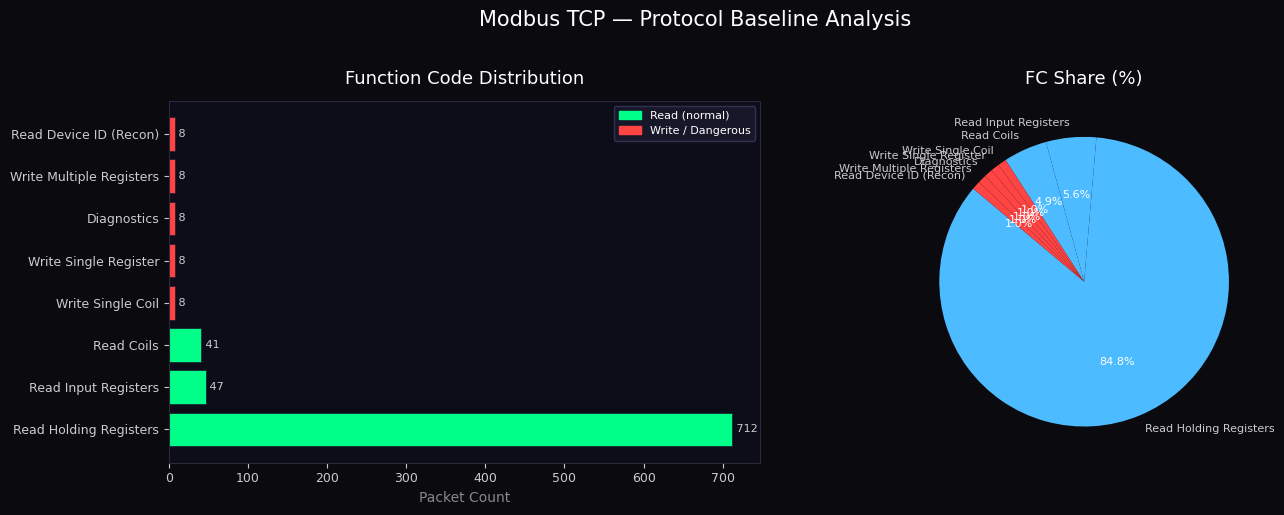

📊 Saved: ../reports/fig1_fc_distribution.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Function code distribution — the fingerprint of this network
# ─────────────────────────────────────────────────────────────────────────────

fc_counts = requests['fc_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A0F')

# Left: bar chart
ax1 = axes[0]
ax1.set_facecolor('#0D0D1A')
colors = [OT_RED if 'Write' in n or 'Diag' in n or 'Recon' in n else OT_GREEN
          for n in fc_counts.index]
bars = ax1.barh(fc_counts.index, fc_counts.values, color=colors, edgecolor='#1A1A2E', linewidth=0.5)
ax1.set_xlabel('Packet Count', color=OT_GREY)
ax1.set_title('Function Code Distribution', color='white', fontsize=13, pad=12)
ax1.tick_params(colors='#CCCCCC', labelsize=9)
ax1.spines[:].set_color('#2A2A3E')
for bar, val in zip(bars, fc_counts.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f' {val}', va='center', color='#CCCCCC', fontsize=8)

from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color=OT_GREEN, label='Read (normal)'),
    Patch(color=OT_RED,   label='Write / Dangerous')
], facecolor='#1A1A2E', edgecolor='#3A3A5E', labelcolor='white', fontsize=8)

# Right: pie chart
ax2 = axes[1]
ax2.set_facecolor('#0D0D1A')
wedge_colors = [OT_RED if 'Write' in n or 'Diag' in n or 'Recon' in n else OT_BLUE
                for n in fc_counts.index]
wedges, texts, autotexts = ax2.pie(
    fc_counts.values,
    labels=fc_counts.index,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'color': '#CCCCCC', 'fontsize': 8},
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax2.set_title('FC Share (%)', color='white', fontsize=13, pad=12)

plt.suptitle('Modbus TCP — Protocol Baseline Analysis', color='white', fontsize=15, y=1.02)
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/fig1_fc_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0A0F')
plt.show()
print("📊 Saved: ../reports/fig1_fc_distribution.png")

---
## Section 4: Anomaly Detection Engine

We apply 5 detection rules derived from real-world ICS threat intelligence:

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: Anomaly Detection — 5 rules modelled on real attack patterns
# ─────────────────────────────────────────────────────────────────────────────

from collections import defaultdict

# ── Define the authorised topology.
#    In a real engagement you'd derive this from network documentation.
#    Here we infer it from the most-frequent source IP.

most_common_src = requests['src_ip'].value_counts().idxmax()
AUTHORISED_MASTERS = {most_common_src}  # the HMI / Engineering Workstation
print(f"Inferred authorised master(s): {AUTHORISED_MASTERS}")

alerts = []

def add_alert(row, severity, rule_id, description, mitre_id, mitre_name):
    alerts.append({
        'timestamp':   row['timestamp'],
        'src_ip':      row['src_ip'],
        'dst_ip':      row['dst_ip'],
        'unit_id':     row['unit_id'],
        'fc':          row['fc_name'],
        'severity':    severity,
        'rule_id':     rule_id,
        'description': description,
        'mitre_id':    mitre_id,
        'mitre_name':  mitre_name,
    })

# ── RULE 1: Write commands from unauthorised sources
WRITE_FCS = {5, 6, 15, 16}
for _, row in requests[requests['function_code'].isin(WRITE_FCS)].iterrows():
    if row['src_ip'] not in AUTHORISED_MASTERS:
        add_alert(row, 'HIGH', 'MODBUS-001',
                  f"Unauthorised Modbus WRITE (FC {row['function_code']}) "
                  f"from {row['src_ip']} to {row['dst_ip']} Unit {row['unit_id']}",
                  'T0836', 'Modify Parameter')

# ── RULE 2: Diagnostic function code — potential PLC restart / DoS
for _, row in requests[requests['function_code'] == 8].iterrows():
    add_alert(row, 'CRITICAL', 'MODBUS-002',
              f"Modbus DIAGNOSTICS (FC 8) from {row['src_ip']} — "
              f"sub-code 0x0001 causes PLC restart. Treat as CRITICAL.",
              'T0816', 'Device Restart/Shutdown')

# ── RULE 3: Device ID reconnaissance (FC 43)
recon_ips = defaultdict(int)
for _, row in requests[requests['function_code'] == 43].iterrows():
    recon_ips[row['src_ip']] += 1
    add_alert(row, 'MEDIUM', 'MODBUS-003',
              f"Device ID read (FC 43) from {row['src_ip']} — reconnaissance indicator",
              'T0846', 'Remote System Discovery')

# ── RULE 4: Unit ID scanning — iterating through slave IDs
src_unit_counts = requests.groupby('src_ip')['unit_id'].nunique()
for src_ip, n_units in src_unit_counts.items():
    if n_units >= 5:   # threshold: querying 5+ different unit IDs
        sample_row = requests[requests['src_ip'] == src_ip].iloc[0]
        add_alert(sample_row, 'MEDIUM', 'MODBUS-004',
                  f"{src_ip} queried {n_units} unique Unit IDs — possible slave scanning",
                  'T0846', 'Remote System Discovery')

# ── RULE 5: High-frequency write burst (>10 writes in 60s from same IP)
write_df = requests[requests['function_code'].isin(WRITE_FCS)].copy()
if not write_df.empty:
    write_df = write_df.sort_values('timestamp')
    write_df['ts_sec'] = write_df['timestamp'].astype('int64') // 10**9
    burst = write_df.groupby(['src_ip', 'ts_sec']).size().reset_index(name='count')
    burst_ips = burst[burst['count'] >= 3]['src_ip'].unique()   # 3/s = 10+/minute
    for ip in burst_ips:
        sample_row = write_df[write_df['src_ip'] == ip].iloc[0]
        add_alert(sample_row, 'HIGH', 'MODBUS-005',
                  f"Write burst detected from {ip} — {burst[burst['src_ip']==ip]['count'].max()} writes/sec",
                  'T0836', 'Modify Parameter')

# ── Format results
alert_df = pd.DataFrame(alerts)
if alert_df.empty:
    print("✅ No anomalies detected with current ruleset.")
else:
    SEV_ORDER = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
    alert_df['sev_order'] = alert_df['severity'].map(SEV_ORDER)
    alert_df = alert_df.sort_values(['sev_order', 'timestamp']).drop(columns='sev_order')
    alert_df.to_csv('../reports/anomaly_alerts.csv', index=False)

    print(f"\n🚨 ANOMALY DETECTION RESULTS — {len(alert_df)} alerts\n")
    print(tabulate(
        alert_df[['severity', 'rule_id', 'src_ip', 'fc', 'mitre_id', 'description']],
        headers=['Severity', 'Rule', 'Source IP', 'FC', 'MITRE', 'Description'],
        tablefmt='fancy_grid',
        showindex=False
    ))
    print("\n📄 Saved: ../reports/anomaly_alerts.csv")

Inferred authorised master(s): {'10.0.0.10'}

🚨 ANOMALY DETECTION RESULTS — 40 alerts

╒════════════╤════════════╤═════════════╤══════════════════════════╤═════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════╕
│ Severity   │ Rule       │ Source IP   │ FC                       │ MITRE   │ Description                                                                                       │
╞════════════╪════════════╪═════════════╪══════════════════════════╪═════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════╡
│ CRITICAL   │ MODBUS-002 │ 10.0.0.99   │ Diagnostics              │ T0816   │ Modbus DIAGNOSTICS (FC 8) from 10.0.0.99 — sub-code 0x0001 causes PLC restart. Treat as CRITICAL. │
├────────────┼────────────┼─────────────┼──────────────────────────┼─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────┤
│ CRITICAL   │ MOD

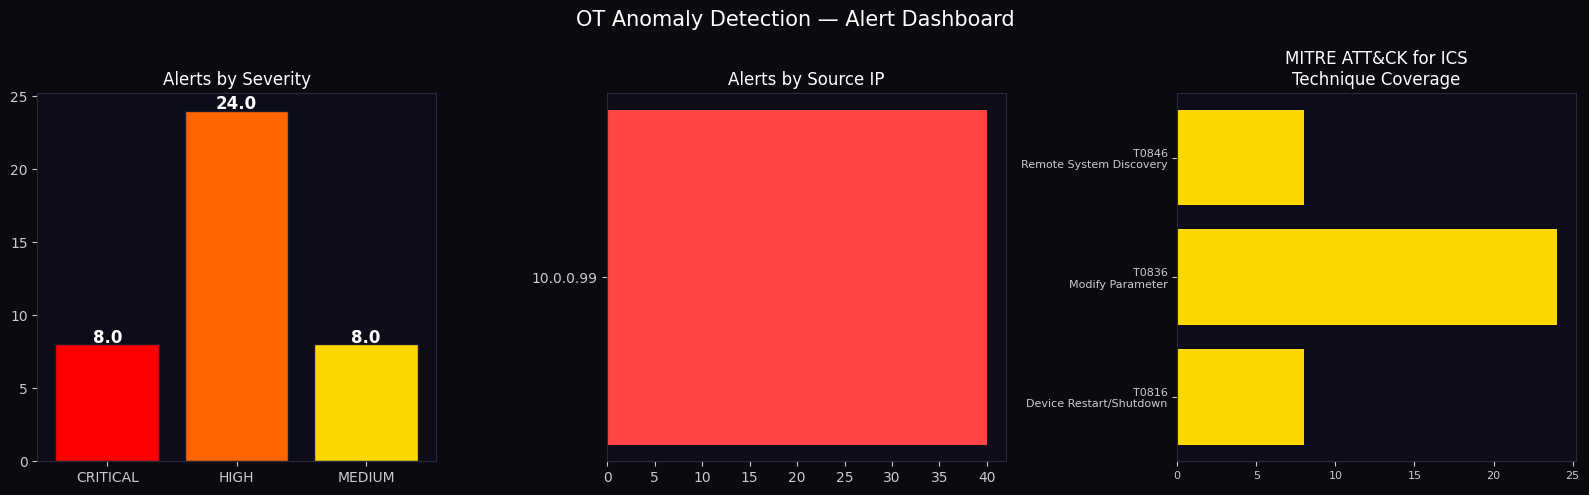

📊 Saved: ../reports/fig2_alert_dashboard.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: Alert Summary Dashboard
# ─────────────────────────────────────────────────────────────────────────────

if not alert_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor('#0A0A0F')

    sev_colors = {'CRITICAL': '#FF0000', 'HIGH': '#FF6600', 'MEDIUM': '#FFD700', 'LOW': '#00FF88'}

    # Plot 1: Alert severity breakdown
    ax1 = axes[0]
    ax1.set_facecolor('#0D0D1A')
    sev_counts = alert_df['severity'].value_counts().reindex(['CRITICAL','HIGH','MEDIUM','LOW']).dropna()
    colors1 = [sev_colors[s] for s in sev_counts.index]
    ax1.bar(sev_counts.index, sev_counts.values, color=colors1, edgecolor='#1A1A2E')
    ax1.set_title('Alerts by Severity', color='white')
    ax1.tick_params(colors='#CCCCCC')
    ax1.spines[:].set_color('#2A2A3E')
    for i, (sev, cnt) in enumerate(sev_counts.items()):
        ax1.text(i, cnt + 0.1, str(cnt), ha='center', color='white', fontsize=12, fontweight='bold')

    # Plot 2: Alerts by source IP
    ax2 = axes[1]
    ax2.set_facecolor('#0D0D1A')
    ip_counts = alert_df['src_ip'].value_counts()
    ax2.barh(ip_counts.index, ip_counts.values, color=OT_RED)
    ax2.set_title('Alerts by Source IP', color='white')
    ax2.tick_params(colors='#CCCCCC')
    ax2.spines[:].set_color('#2A2A3E')

    # Plot 3: MITRE ATT&CK mapping
    ax3 = axes[2]
    ax3.set_facecolor('#0D0D1A')
    mitre_counts = alert_df.groupby(['mitre_id', 'mitre_name']).size().reset_index(name='count')
    mitre_labels = [f"{r.mitre_id}\n{r.mitre_name}" for _, r in mitre_counts.iterrows()]
    ax3.barh(mitre_labels, mitre_counts['count'], color=OT_YELLOW)
    ax3.set_title('MITRE ATT&CK for ICS\nTechnique Coverage', color='white')
    ax3.tick_params(colors='#CCCCCC', labelsize=8)
    ax3.spines[:].set_color('#2A2A3E')

    plt.suptitle('OT Anomaly Detection — Alert Dashboard', color='white', fontsize=15)
    plt.tight_layout()
    plt.savefig('../reports/fig2_alert_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0A0A0F')
    plt.show()
    print("📊 Saved: ../reports/fig2_alert_dashboard.png")

---
## Section 5: Traffic Timeline — Spotting the Attack Window

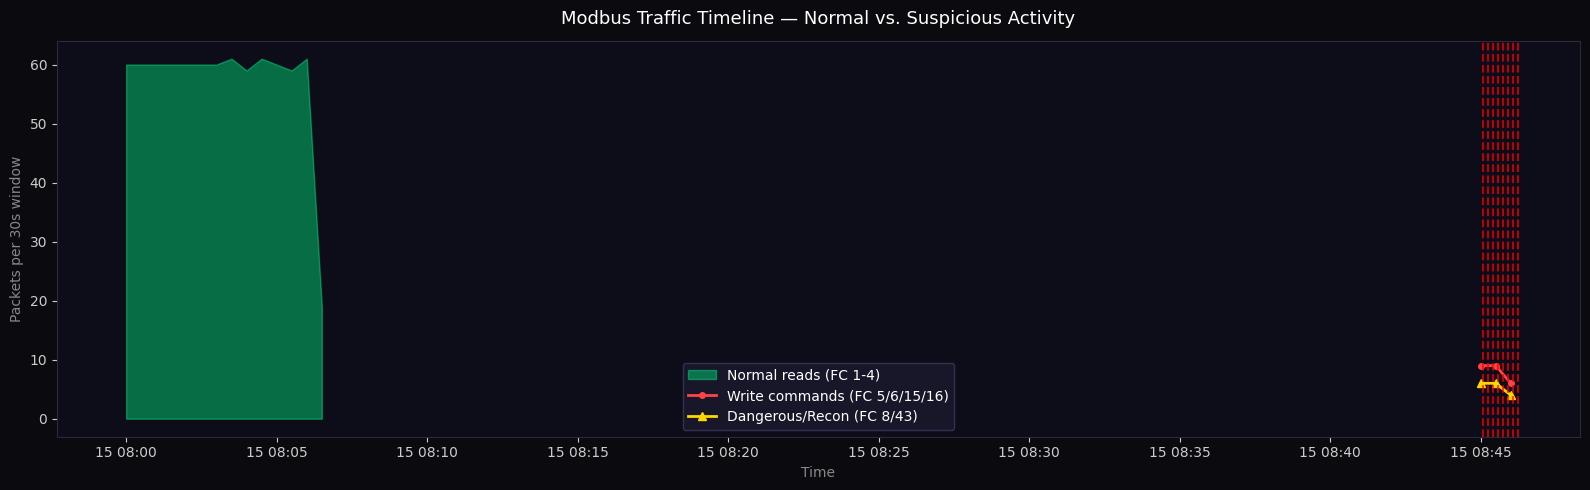

📊 Saved: ../reports/fig3_traffic_timeline.png


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: Timeline visualisation — normal vs. suspicious traffic over time
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0A0A0F')
ax.set_facecolor('#0D0D1A')

# All requests binned per minute
all_req = requests.copy()
all_req = all_req.set_index('timestamp').sort_index()

normal_req  = all_req[all_req['function_code'].isin([1,2,3,4])]
write_req   = all_req[all_req['function_code'].isin([5,6,15,16])]
danger_req  = all_req[all_req['function_code'].isin([8, 43])]

def resample_count(df_in, freq='30s'):
    if df_in.empty:
        return pd.Series(dtype=float)
    return df_in.resample(freq).size()

ax.fill_between(resample_count(normal_req).index,
                resample_count(normal_req).values,
                alpha=0.4, color=OT_GREEN, label='Normal reads (FC 1-4)')
ax.plot(resample_count(write_req).index,
        resample_count(write_req).values,
        color=OT_RED, linewidth=2, label='Write commands (FC 5/6/15/16)', marker='o', markersize=4)
ax.plot(resample_count(danger_req).index,
        resample_count(danger_req).values,
        color=OT_YELLOW, linewidth=2, label='Dangerous/Recon (FC 8/43)', marker='^', markersize=6)

# Mark alert timestamps
if not alert_df.empty:
    crit_alerts = alert_df[alert_df['severity'] == 'CRITICAL']
    for _, row in crit_alerts.iterrows():
        ax.axvline(x=row['timestamp'], color='#FF0000', linewidth=1.5, alpha=0.7, linestyle='--')

ax.set_title('Modbus Traffic Timeline — Normal vs. Suspicious Activity',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Time', color=OT_GREY)
ax.set_ylabel('Packets per 30s window', color=OT_GREY)
ax.tick_params(colors='#CCCCCC')
ax.spines[:].set_color('#2A2A3E')
ax.legend(facecolor='#1A1A2E', edgecolor='#3A3A5E', labelcolor='white')

plt.tight_layout()
plt.savefig('../reports/fig3_traffic_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0A0A0F')
plt.show()
print("📊 Saved: ../reports/fig3_traffic_timeline.png")

---
## Section 6: Analyst Incident Report

This is the most important section for your portfolio. This is what you'd hand to a SOC lead.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: Auto-generate analyst incident report in Markdown
# ─────────────────────────────────────────────────────────────────────────────

from datetime import datetime as dt

total_pkts     = len(df)
total_modbus   = len(requests)
unique_srcs    = requests['src_ip'].nunique()
unique_dsts    = requests['dst_ip'].nunique()
total_alerts   = len(alert_df)
crit_count     = (alert_df['severity'] == 'CRITICAL').sum() if not alert_df.empty else 0
high_count     = (alert_df['severity'] == 'HIGH').sum()     if not alert_df.empty else 0
rogue_ips      = sorted(set(alert_df['src_ip'].unique()) - AUTHORISED_MASTERS) if not alert_df.empty else []

report = f"""# ICS Security Incident Report

| Field | Value |
|---|---|
| **Report Date** | {dt.now().strftime('%Y-%m-%d %H:%M UTC')} |
| **Analyst** | [Your Name] |
| **Source** | Modbus TCP PCAP analysis |
| **Classification** | TLP:AMBER |

---

## Executive Summary

Analysis of {total_pkts:,} network packets revealed {total_modbus:,} Modbus TCP
transactions between {unique_srcs} source hosts and {unique_dsts} destination devices.
The automated detection engine generated **{total_alerts} alerts** including
**{crit_count} CRITICAL** and **{high_count} HIGH** severity findings.

{'⚠️  INCIDENT DECLARED: Unauthorised write and diagnostic commands were detected from rogue IP(s): ' + ', '.join(rogue_ips) if rogue_ips else '✅ No unauthorised source IPs identified in this capture window.'}

---

## Technical Findings

### 1. Network Topology Baseline

- **Authorised Master(s):** `{', '.join(AUTHORISED_MASTERS)}`
  *(inferred from traffic dominance — confirm against network documentation)*
- **Modbus TCP Port:** 502
- **Purdue Model Placement:** Level 2 (SCADA/HMI) → Level 1 (PLC/RTU)

### 2. Function Code Profile

{requests['fc_name'].value_counts().to_markdown()}

### 3. Anomalies Detected

{'No anomalies detected.' if alert_df.empty else alert_df[['severity','rule_id','src_ip','fc','mitre_id','mitre_name','description']].to_markdown(index=False)}

---

## MITRE ATT&CK for ICS Coverage

| Technique ID | Name | Tactic | Detected |
|---|---|---|---|
| T0836 | Modify Parameter | Impair Process Control | {'✅' if 'T0836' in alert_df.get('mitre_id', pd.Series()).values else '—'} |
| T0816 | Device Restart/Shutdown | Inhibit Response Function | {'✅' if 'T0816' in alert_df.get('mitre_id', pd.Series()).values else '—'} |
| T0846 | Remote System Discovery | Discovery | {'✅' if 'T0846' in alert_df.get('mitre_id', pd.Series()).values else '—'} |
| T0843 | Program Upload | Collection | — |

---

## Recommendations

1. **Firewall ACL:** Restrict Modbus TCP (port 502) to authorised master IPs only at the
   Level 3.5 DMZ firewall. No engineering workstation except the designated HMI should
   originate Modbus writes.

2. **IDS Rules:** Deploy Suricata rules MODBUS-001 through MODBUS-005 (see `ot_detection.rules`)
   on the OT network tap.

3. **Protocol Whitelisting:** If function codes 5, 6, 15, 16 are not operationally required
   from any host, block them at a Modbus-aware firewall (e.g. Dragos, Claroty).

4. **Asset Inventory Validation:** Cross-reference discovered Unit IDs against the current
   asset register. Undocumented Unit IDs are an incident in themselves.

5. **Compliance Note (NIST SP 800-82 Rev 3):** This finding maps to Control SI-3
   (Malicious Code Protection) and AC-3 (Access Enforcement) in the ICS security overlay.

---

*Generated by: modbus_analyzer.ipynb | Tools: Python, Scapy, Pandas, Matplotlib*
"""

report_path = '../reports/incident_report.md'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\n✅ Report saved to {report_path}")

# ICS Security Incident Report

| Field | Value |
|---|---|
| **Report Date** | 2026-05-24 17:02 UTC |
| **Analyst** | [Your Name] |
| **Source** | Modbus TCP PCAP analysis |
| **Classification** | TLP:AMBER |

---

## Executive Summary

Analysis of 840 network packets revealed 840 Modbus TCP 
transactions between 2 source hosts and 3 destination devices.
The automated detection engine generated **40 alerts** including 
**8 CRITICAL** and **24 HIGH** severity findings.

⚠️  INCIDENT DECLARED: Unauthorised write and diagnostic commands were detected from rogue IP(s): 10.0.0.99

---

## Technical Findings

### 1. Network Topology Baseline

- **Authorised Master(s):** `10.0.0.10`  
  *(inferred from traffic dominance — confirm against network documentation)*
- **Modbus TCP Port:** 502
- **Purdue Model Placement:** Level 2 (SCADA/HMI) → Level 1 (PLC/RTU)

### 2. Function Code Profile

| fc_name                  |   count |
|:-------------------------|--------:|
| Read Holding Registers   |

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
!apt-get update
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,947 kB]
Get:14 

In [36]:
# Now that xelatex is installed, run nbconvert to generate the PDF
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/modbus_analyzer.ipynb" --output-dir "/content/drive/MyDrive/Colab Notebooks"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/modbus_analyzer.ipynb to pdf
[NbConvertApp] Support files will be in modbus_analyzer_files/
[NbConvertApp] Making directory ./modbus_analyzer_files
[NbConvertApp] Writing 180427 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 290413 bytes to /content/drive/MyDrive/Colab Notebooks/modbus_analyzer.pdf
